<div style="border-bottom: 4px solid #003366; margin-bottom: 20px; padding-bottom: 10px; display: flex; justify-content: space-between; align-items: center;">
    <div style="flex-grow: 1;">
        <h1 style="color: #003366; font-family: 'Helvetica', sans-serif; margin-bottom: 5px;">MAT2605: Cálculo Científico I</h1>
        <h2 style="color: #555; margin-top: 0; margin-bottom: 10px;">Laboratorio 02: Sistemas lineales, M&eacute;todos directos</h2>
        <p style="margin: 2px 0;"><b>Profesores:</b> Thomas F&uuml;hrer y Manuel A. Sánchez | <b>Fecha:</b> 20 de Marzo, 2026</p>
        <p style="margin: 2px 0;"><b>Institución:</b> Facultad de Matemáticas, Pontificia Universidad Católica de Chile</p>
    </div>
    <div style="flex: 0 0 auto; margin-left: 20px;">
        <img src="../source/FacMatematicas-15.png" 
             alt="Logo UC" 
             style="height: 60px; width: auto;">
    </div>

</div>

<div style="border: 1px solid #2980b9; border-left: 8px solid #2980b9; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2980b9; margin-top: 0;">🎯 Objetivos de la Sesión</h3>
    <ul>
        <li>C&aacute;lculo costo computacional, efecto en tiempo.</li>
        <li>Orden experimental</li>
        <li>Eliminaci&oacute;n de Gauss.</li>
    </ul>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px; margin-bottom: 20px;">
    <h3 style="color: #2e7d32; margin-top: 0;">👤 Identificación del Estudiante</h3>
    <p style="margin-bottom: 10px; color: #555;">Por favor, completa tus datos antes de comenzar:</p>
    <ul style="list-style-type: none; padding-left: 0; color: #333;">
        <li style="margin-bottom: 5px;"><b>📌 Nombre Completo:</b> _______________________________________</li>
        <li style="margin-bottom: 5px;"><b>📌 Rol / Nº Alumno:</b> _________________________</li>
    </ul>
    <p style="font-size: 0.85em; color: #2e7d32; margin-top: 15px; border-top: 1px solid #a5d6a7; padding-top: 5px;">
        <i>💡 Haz doble clic en esta celda para editarla con tus datos.</i>
    </p>
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys

# INTENTO DE CONFIGURACIÓN DE ESTILO (Compatible con versiones viejas y nuevas)
try:
    plt.style.use('seaborn-v0_8-whitegrid') # Nombre nuevo (Matplotlib 3.6+)
except OSError:
    plt.style.use('seaborn-whitegrid')      # Nombre antiguo

plt.rcParams['figure.figsize'] = (10, 6)

print(f"Versión de Numpy: {np.__version__}")
print(f"Estilo usado: {plt.style.context}")

Versión de Numpy: 2.4.2
Estilo usado: <function context at 0x7fd17223b690>


<div class="alert-block alert-warning "; style=" border-left: 5px solid #ffc107; padding: 15px; border-radius: 5px;">
    <h2 > Costo computacional </h2>
    <h3 style="color: #d35400; margin-top: 0;">📚 Teoría:</h3>
    <p>Para facilitar el c&aacute;lculo del costo computacional de un algoritmo, contamos la cantidad de operaciones aritm&eacute;ticas.</p>
    <p>Producto interior de dos vectores $x$, $y\in\mathbb{R}^N$:</p>
    $$ x\cdot y = \sum_{j=1}^N x_j y_j = x_1y_1 + x_2y_2 + \ldots + x_Ny_N$$
    <p>Nota que para calcular la suma se requiere $N$ multiplicaciones y $N-1$ adiciones, entonces el costo computacional es</p>
    $$\mathrm{costo} = 2N-1 = \mathcal{O}(N) \quad\text{cuando } N\to \infty$$
</div>


## Comparaci&oacute;n entre costo cuadr&aacute;tico $\mathcal{O}(N^2)$ y costo c&uacute;bico $\mathcal{O}(N^3)$

El costo para calcular el producto $Ax$, donde $A\in\mathbb{R}^{N\times N}$, $x\in\mathbb{R}^N$ es $\mathcal{O}(N^2)$, mientras el costo para calcular $AB$ donde $A,B\in \mathbb{R}^{N\times N}$ es $\mathcal{O}(N^3)$

In [2]:
import numpy as np
import time # para medir tiempo

# Repetimos los calculos M veces (tomando los promedios)
M = 10

## MATRIZ - VECTOR
n = 13
tiempoMatVec = np.zeros(n) 
for k in range(M):
    # para N = 2^0, 2^1, 2^2, ..., 2^{n-1} medimos el tiempo para determinar el producto interior

    for j in range(n):
        N = 2**j
        # Generar vector con valores aleatorias
        x = np.random.rand(N)
        # Generar matrices NxN
        A = np.random.rand(N, N)
        
        # Ax
        tInicio = time.time()
        tmp = A*x
        tFin = time.time()
        tiempoMatVec[j] = tiempoMatVec[j]+tFin-tInicio
    
# Tomar los promedios
tiempoMatVec = tiempoMatVec/M
N_MatVec = [2**j for j in range(n)] # usamos despues

## MATRIZ - MATRIZ
n = 10
tiempoMatMat = np.zeros(n)

for k in range(M):
    # para N = 2^0, 2^1, 2^2, ..., 2^{n-1} medimos el tiempo para determinar el producto interior

    for j in range(n):
        N = 2**j
        # Generar matrices NxN
        A = np.random.rand(N, N)
        B = np.random.rand(N, N)
    
        # AB
        tInicio = time.time()
        tmp = A@B
        tFin = time.time()
        tiempoMatMat[j] = tiempoMatMat[j]+tFin-tInicio

# Tomar los promedios
tiempoMatMat = tiempoMatMat/M

N_MatMat = [2**j for j in range(n)] # usamos despues

### Visualicaci&oacute;n de los resultados

Para visualizar el tiempo, usaremos un plot doble-logar&iacute;tmico

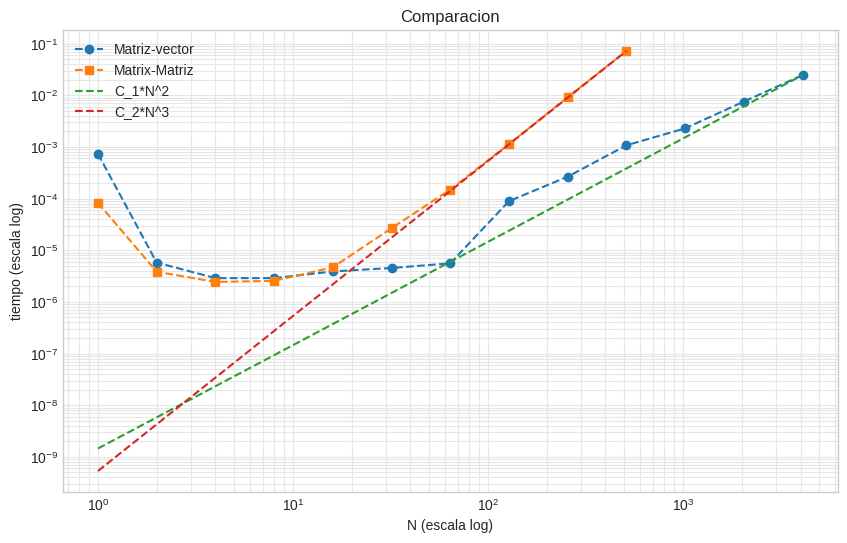

In [31]:
plt.loglog(N_MatVec, tiempoMatVec, marker='o', linestyle='--',label="Matriz-vector") 
plt.loglog(N_MatMat, tiempoMatMat, marker='s', linestyle='--',label="Matrix-Matriz") 
plt.loglog(N_MatVec, [tiempoMatVec[-1]/(N_MatVec[-1]**2)*j**2 for j in N_MatVec], linestyle='--',label="C_1*N^2") 
plt.loglog(N_MatMat, [tiempoMatMat[-1]/(N_MatMat[-1]**3)*j**3 for j in N_MatMat], linestyle='--',label="C_2*N^3") 
plt.xlabel("N (escala log)")
plt.ylabel("tiempo (escala log)")
plt.title("Comparacion")
plt.grid(True, which="both", ls="-", color='0.9') # Add major and minor gridlines
plt.legend()

### Presentaci&oacute;n mediante tabla: El orden experimental

El orden experimental $\alpha$ se puede determinar de la siguiente manera:

Asumimos $f(N) = \mathcal{O}(N^\alpha)$ para $N\to \infty$. Tenemos los datos $(N_j,f(N_j))$, $j=1,2,\ldots,K$.

Ahora consideramos $(\log(N_j),\log(f(N_j)))$ y tenemos que $\log(f(N_j)) \approx \alpha \log(N_j)$ seg&uacute;n suposici&oacute;n. 

El orden experimental $\alpha_j$ se obtiena al calcular la pendiente de la recta que conecta $(\log(N_{j-1}),\log(f(N_{j-1})))$ y $(\log(N_j),\log(f(N_j)))$. Es decir, 
$$\alpha_j = \frac{\log(f(N_j))-\log(f(N_{j-1}))}{\log(N_j)-\log(N_{j-1})}, \quad j=2,...,K.$$


In [68]:
import numpy as np
import pandas as pd

print("Tiempo para calcular producto matricial A*B")

difLogN = np.log(N_MatMat[1:])-np.log(N_MatMat[:-1])
difLogFN = np.log(tiempoMatMat[1:])-np.log(tiempoMatMat[:-1])
alpha = np.concatenate(([0], difLogFN / difLogN))


df_round = pd.DataFrame({
    "N": N_MatMat,
    "tiempo": tiempoMatMat, 
    "orden experimental": np.round(alpha, 2)
})

# display() formatea la tabla mucho mejor que print() en Jupyter
display(df_round)

Tiempo para calcular producto matricial A*B


,N,tiempo,orden experimental
0,1,0.000083,0.00
1,2,0.000004,-4.43
2,4,0.000002,-0.66
3,8,0.000003,0.07
4,16,0.000005,0.87
5,32,0.000027,2.52
6,64,0.000149,2.48
7,128,0.001129,2.92
8,256,0.009156,3.02
9,512,0.071746,2.97


---
<div class="alert alert-block alert-success"> 

## Evaluaci&oacute;n:

</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Pregunta 1</h3>
    <p>La pregunta se enuncia durante el laboratorio</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [12]:
# Espacio para tu código



<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Pregunta 2</h3>
    <p>La pregunta se enuncia durante el laboratorio</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [13]:
# Espacio para tu código



<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #2e7d32; margin-top: 0;">💻 Pregunta 3</h3>
    <p>La pregunta se enuncia durante el laboratorio</p>
</div>

<div style="background-color: #e8f5e9; border-left: 5px solid #4caf50; padding: 15px; border-radius: 5px;">
    <h3 style="color: #6a1b9a; margin: 0; font-size: 1.1em;">
        ✏️ Solución / Desarrollo
    </h3>
    <p style="margin: 5px 0 0 0; font-size: 0.9em; color: #666;">
        <i>Utilice las celdas de código y texto debajo de esta línea para responder. Recuerde comentar su código.</i>
    </p>
</div>

In [14]:
# Espacio para tu código



<div style="width: 100%; border-top: 2px solid #ddd; padding-top: 15px; margin-top: 30px; font-family: sans-serif; font-size: 0.85em; color: #666;">
    <p>
        <strong>© 2026 Thomas Fuhrer & Manuel A. Sánchez </strong><br>
        Profesores, <a href="https://www.mat.uc.cl/" style="color: #003366; text-decoration: none;">Facultad de Matemáticas</a><br>
        Pontificia Universidad Católica de Chile
    </p>
    <p>
        <i>Este material está diseñado para el curso MAT2605 y no debe ser redistribuido sin permiso explícito.</i>
    </p>
</div>